# Signal Denoising by Moving Average Filter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

In [2]:
# create signal

srate = 256 # Hz
t = np.arange(0,3,1/srate)
pnts = len(t)

# creating a noiseless signal
x = np.sin(2*np.pi*2*t)

# creating a random noise
noise = 5 * np.random.randn(pnts)


# adding noise on signal 
noisy_signal = x + noise

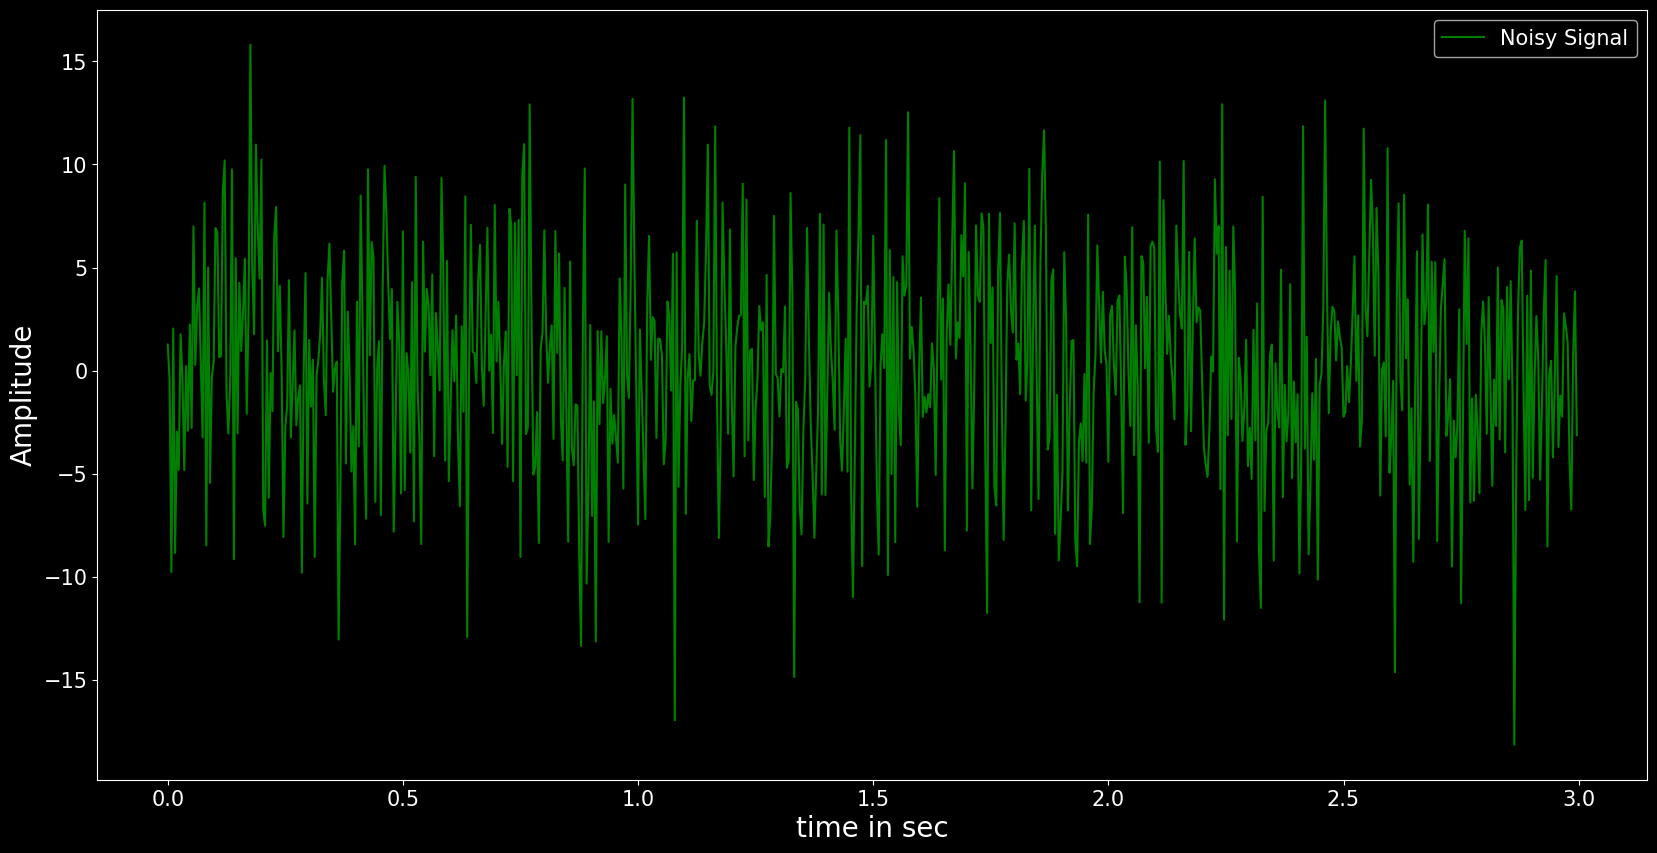

In [4]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

N = order of moving average filter. FilterWindow is actually (2N +1). 
Increasing the order of filter will increase the smoothness of filtered signal

In [5]:
N = 30

In [6]:
noisy_signal.shape[0]

768

In [7]:
# Initialize denoised signal
filtered_signal = np.zeros(noisy_signal.shape[0])

In [8]:
# Apply moving average filter

for i in range(0, noisy_signal.shape[0]):
	filtered_signal[i] = np.mean( noisy_signal[i:(2*N +1) + i])

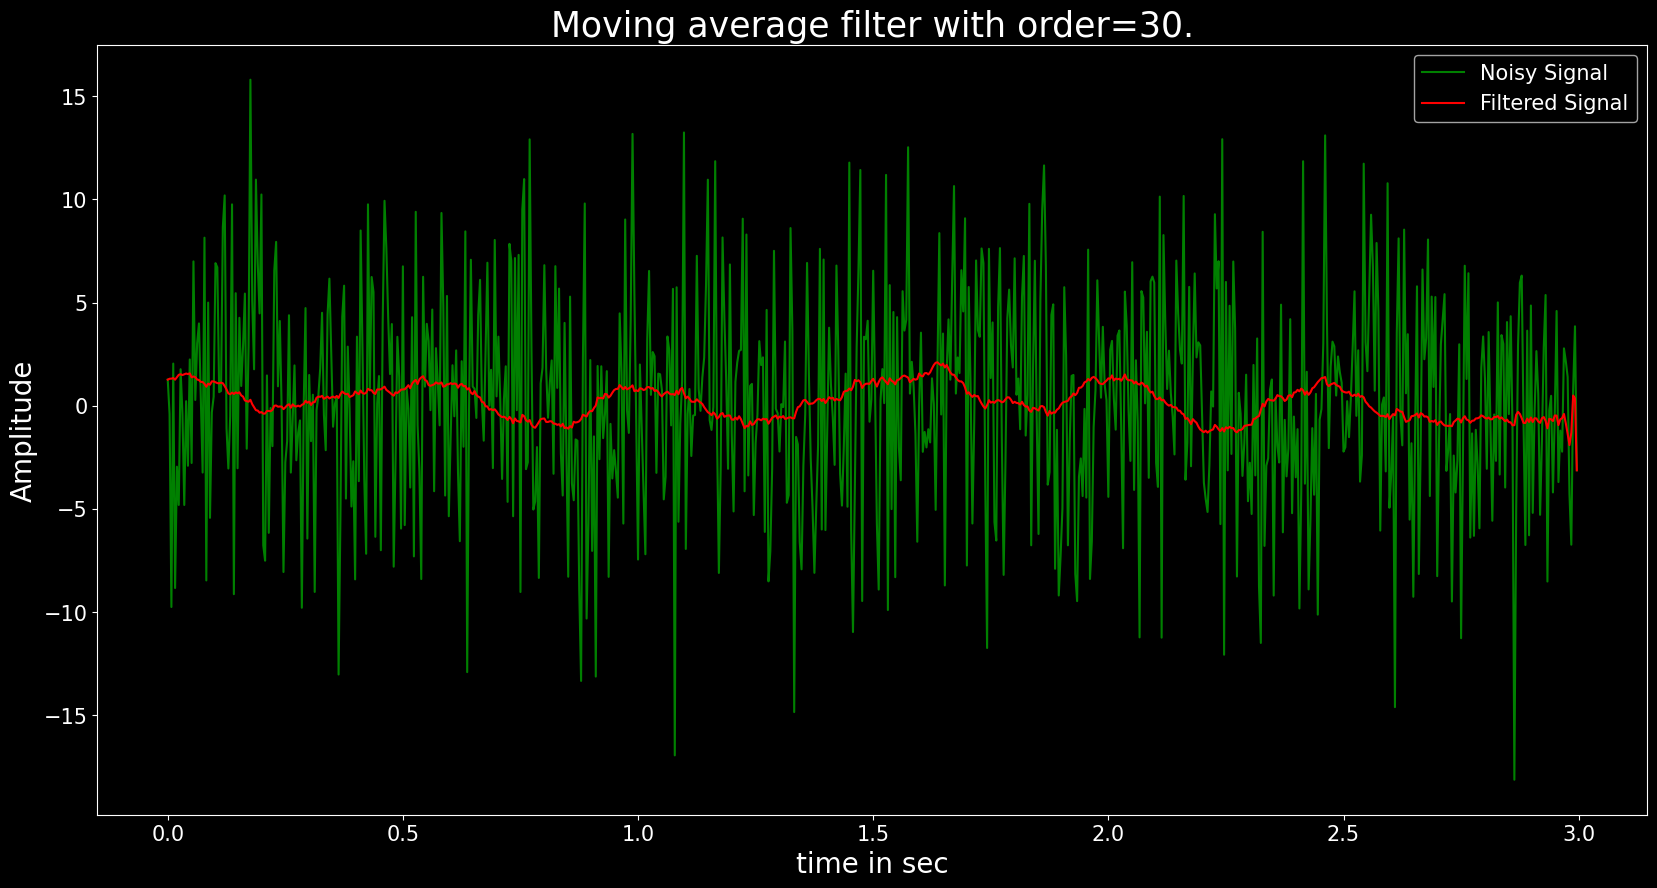

In [9]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g-', label = 'Noisy Signal')
plt.plot(t,filtered_signal, 'r-', label = 'Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Moving average filter with order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Signal denoising by Gaussian Mean Filter

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import style

In [3]:
# create signal

srate = 512 # Hz
t = np.arange( 0, 3, 1 / srate)

pnts = len(t)

# creating a noiseless signal 
x = np.sin(2 * np.pi * 2 * t)

# creating a random noise
noise = 5 * np.random.randn(pnts)

# adding noise on signal 
noisy_signal = x + noise

In [4]:
print(pnts)

1536


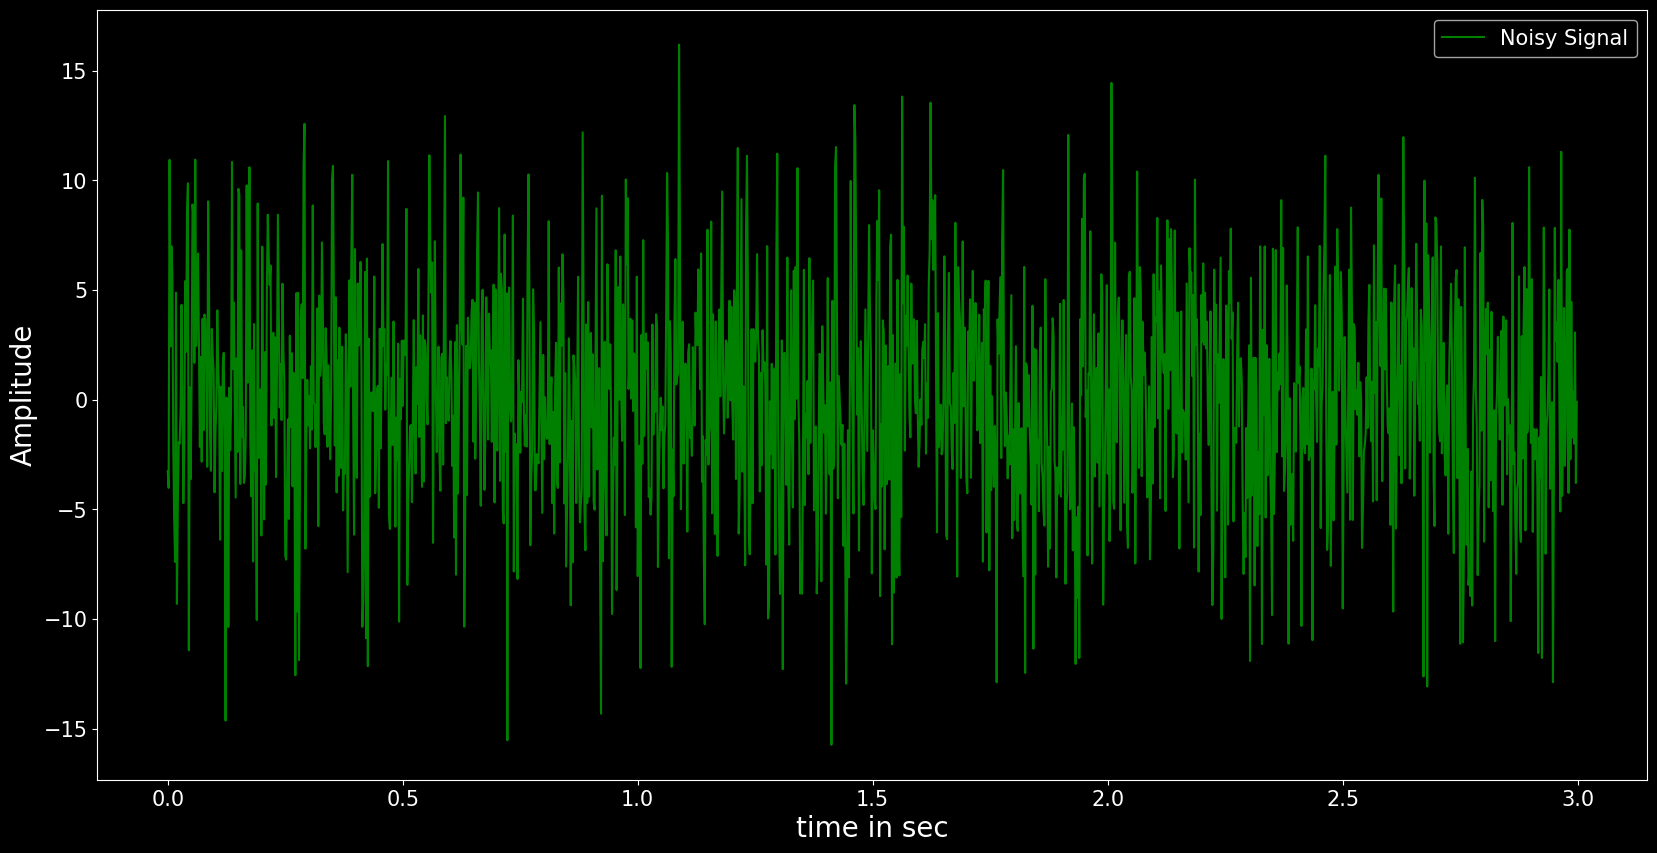

In [6]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

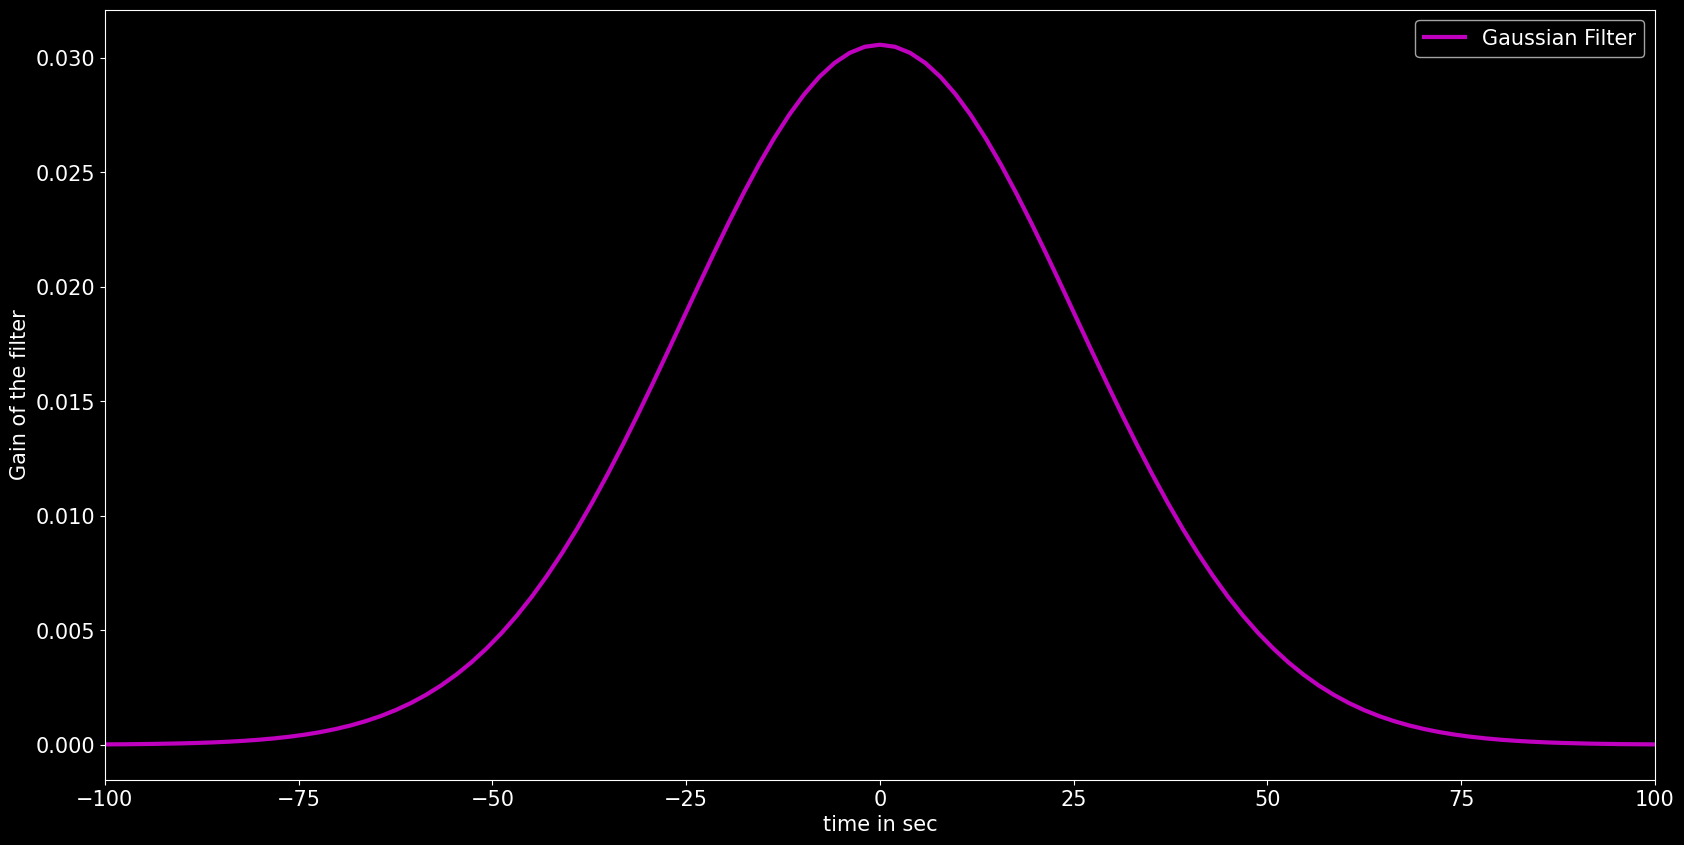

In [7]:
# Generating Gaussian filter / kernel 

N = 100 
fwhm = 60 # ms # full-width half-max
Gtime = 1000 * np.arange(-N, N)/srate # since fwhm is in ms, therefore we multiply it by 1000 to get Gtime in ms

Gfilter = np.exp( -(4 * np.log(2) * Gtime**2) / fwhm**2)  # generating gaussian filter
Gfilter = Gfilter / np.sum(Gfilter) # normalizing the Gaussian Filter 


# plotting Gaussian filter 

plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(Gtime, Gfilter, 'm',linewidth=3,  label = 'Gaussian Filter')
plt.xlabel('time in sec', fontsize = 15)
plt.ylabel('Gain of the filter', fontsize = 15)
plt.xlim([-100,100])
plt.legend(fontsize = 15)
plt.show()

Zero padding the noisy signal to avoid edge effect 

In [8]:
sig_4_filter = np.concatenate ((np.zeros(N), noisy_signal, np.zeros(N)), axis=0) # zero padding to avoid edge effect 

K = len(noisy_signal)

timeindex = np.concatenate (( np.arange(-N, 0), np.arange(0, K), np.arange(K, K+N)), axis = 0)
time_4_filter = timeindex / srate

In [9]:
print(len(sig_4_filter))
print(len(timeindex))

1736
1736


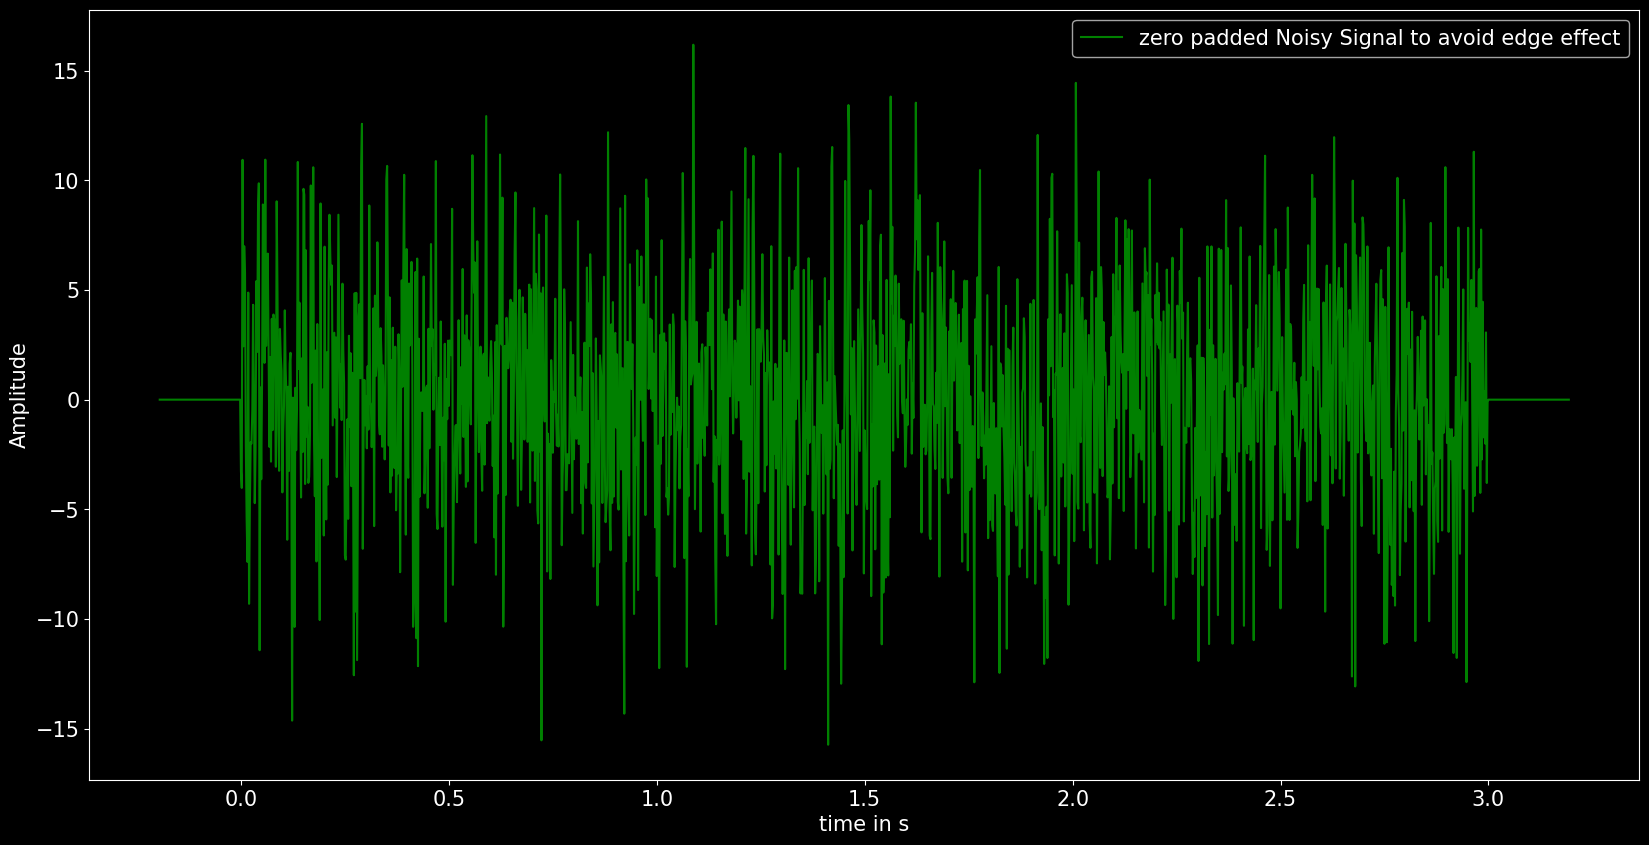

In [11]:
plt.figure(figsize= (20,10))
plt.plot(time_4_filter, sig_4_filter, 'g', label = 'zero padded Noisy Signal to avoid edge effect')
plt.xlabel('time in s', fontsize = 15)
plt.ylabel('Amplitude', fontsize = 15)
plt.legend(fontsize = 15)

In [13]:
# Initialize the filtered signal

Gfilt_sig = np.zeros(sig_4_filter.shape[0])

# Apply Gaussian Filter 

for i in range(0, noisy_signal.shape[0]): 
    Gfilt_sig[i] = np.sum(sig_4_filter[i:2 * N + i] * Gfilter)

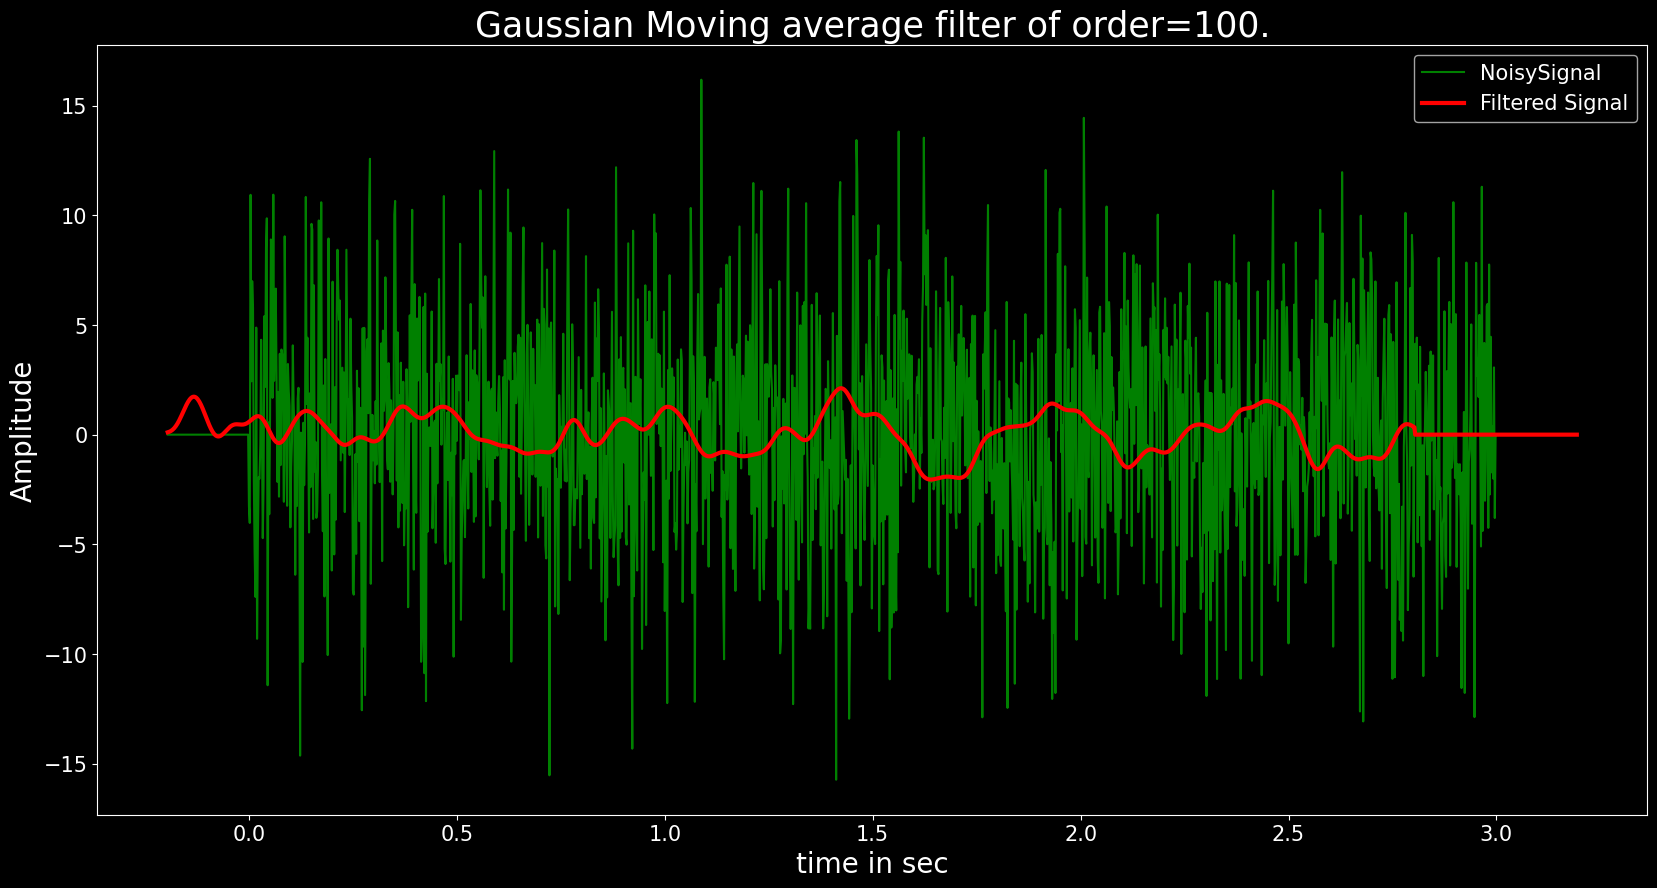

In [15]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(time_4_filter, sig_4_filter, 'g-', label = 'NoisySignal')
plt.plot(time_4_filter, Gfilt_sig, 'r-',linewidth = 3,  label = 'Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Gaussian Moving average filter of order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

In [16]:
Gfilt_sig_clipped = Gfilt_sig[0:K] # clip off the edges to avoid edge effect

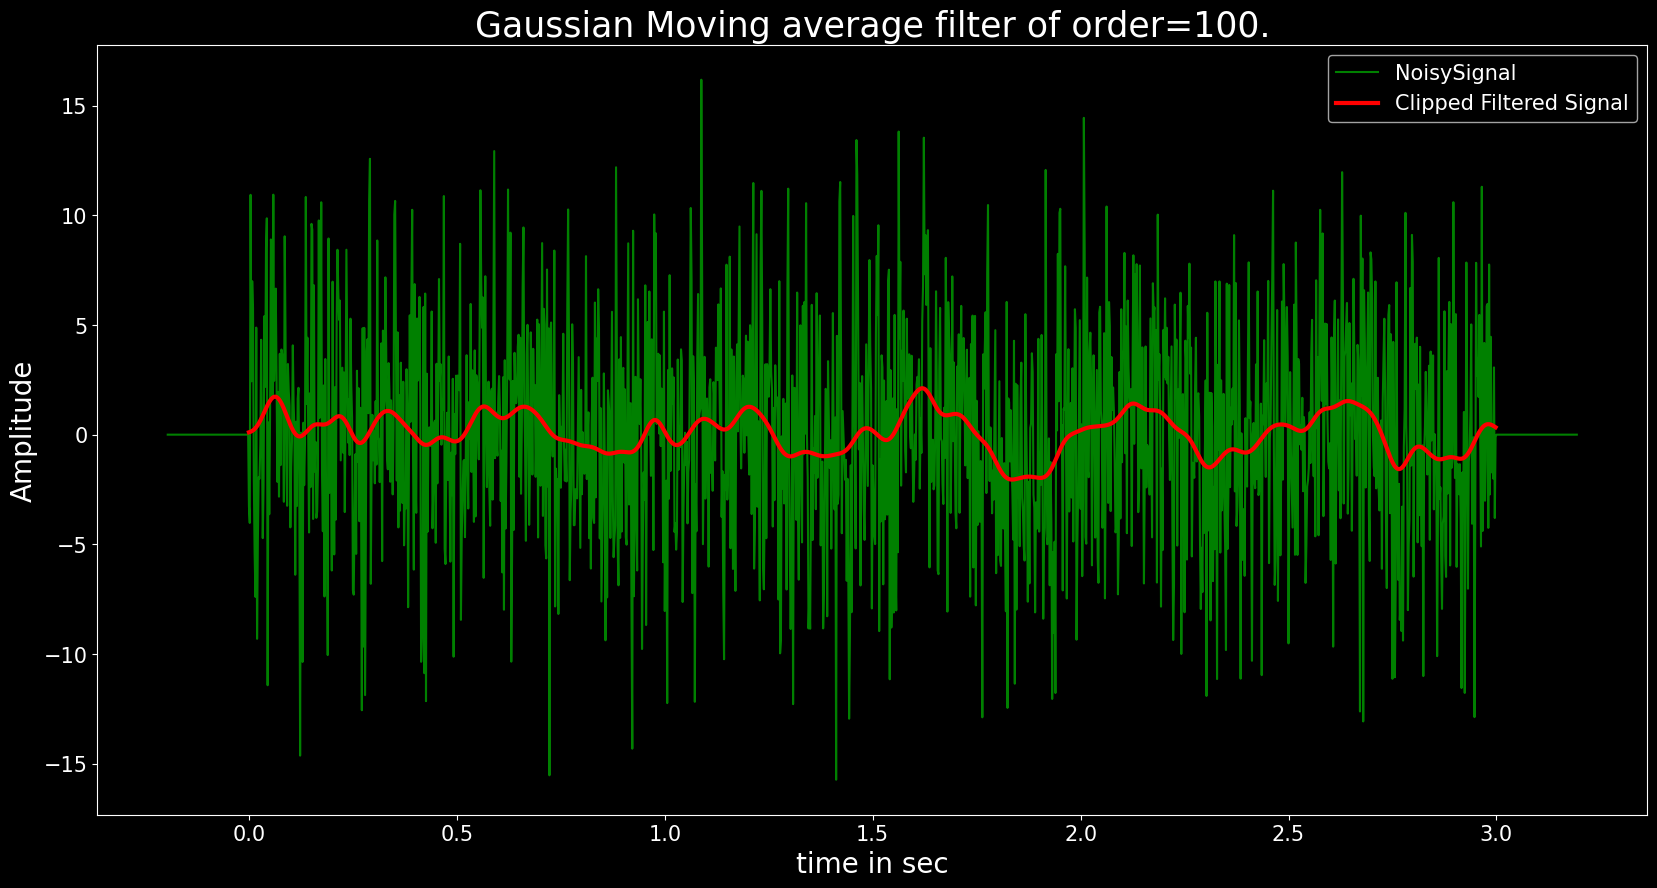

In [17]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(time_4_filter, sig_4_filter, 'g-', label = 'NoisySignal')
plt.plot(t, Gfilt_sig_clipped, 'r-',linewidth = 3,  label = 'Clipped Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Gaussian Moving average filter of order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Signal denoising by Median Filter

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import style

In [2]:
# create signal 
srate = 256 # Hz
t = np.arange( 0, 3, 1 / srate)
pnts = len(t)

# creating a noiseless signal
x = np.sin( 2 * np.pi * 2 * t)

# creating a random noise
noise = 5 * np.random.randn(pnts)

# Adding noise on signal 
signal = x + noise 




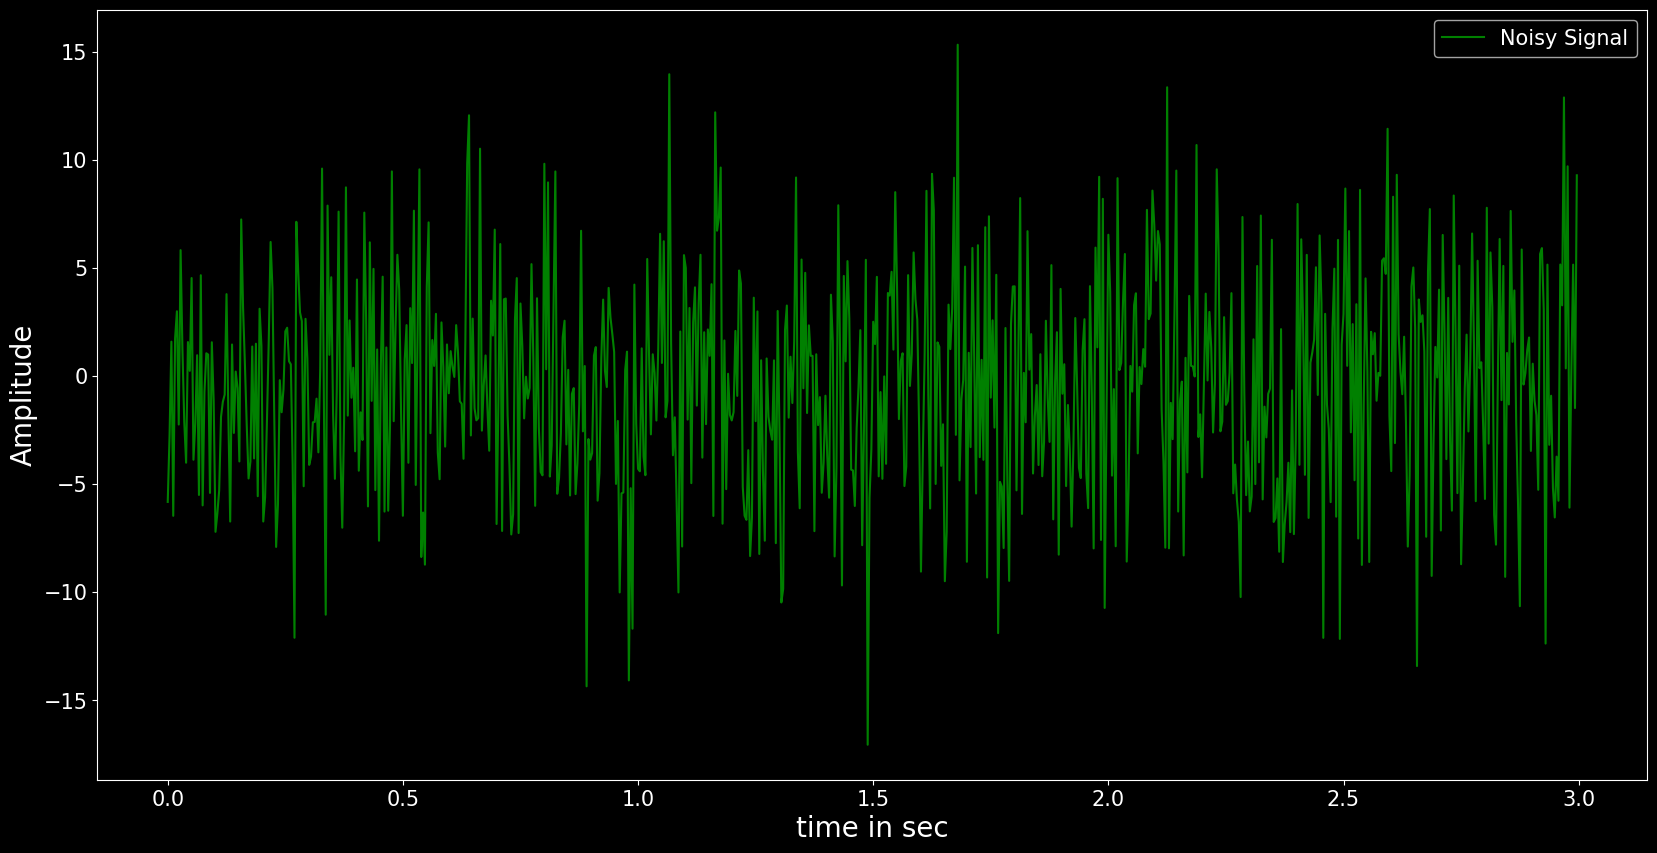

In [4]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t, signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

In [5]:
N = 50

# Initialize denoised signal
filt_sig = np.zeros(signal.shape[0])

In [10]:
# Apply Median filter 

for i in range(0, signal.shape[0]): 
    filt_sig[i] = np.median(signal[i: N + i])

In [11]:
# Applying moving average filter 
mean_filt_sig = np.zeros(signal.shape[0])
for i in range(0, signal.shape[0]): 
    mean_filt_sig[i] = np.mean(signal[i: N +i])

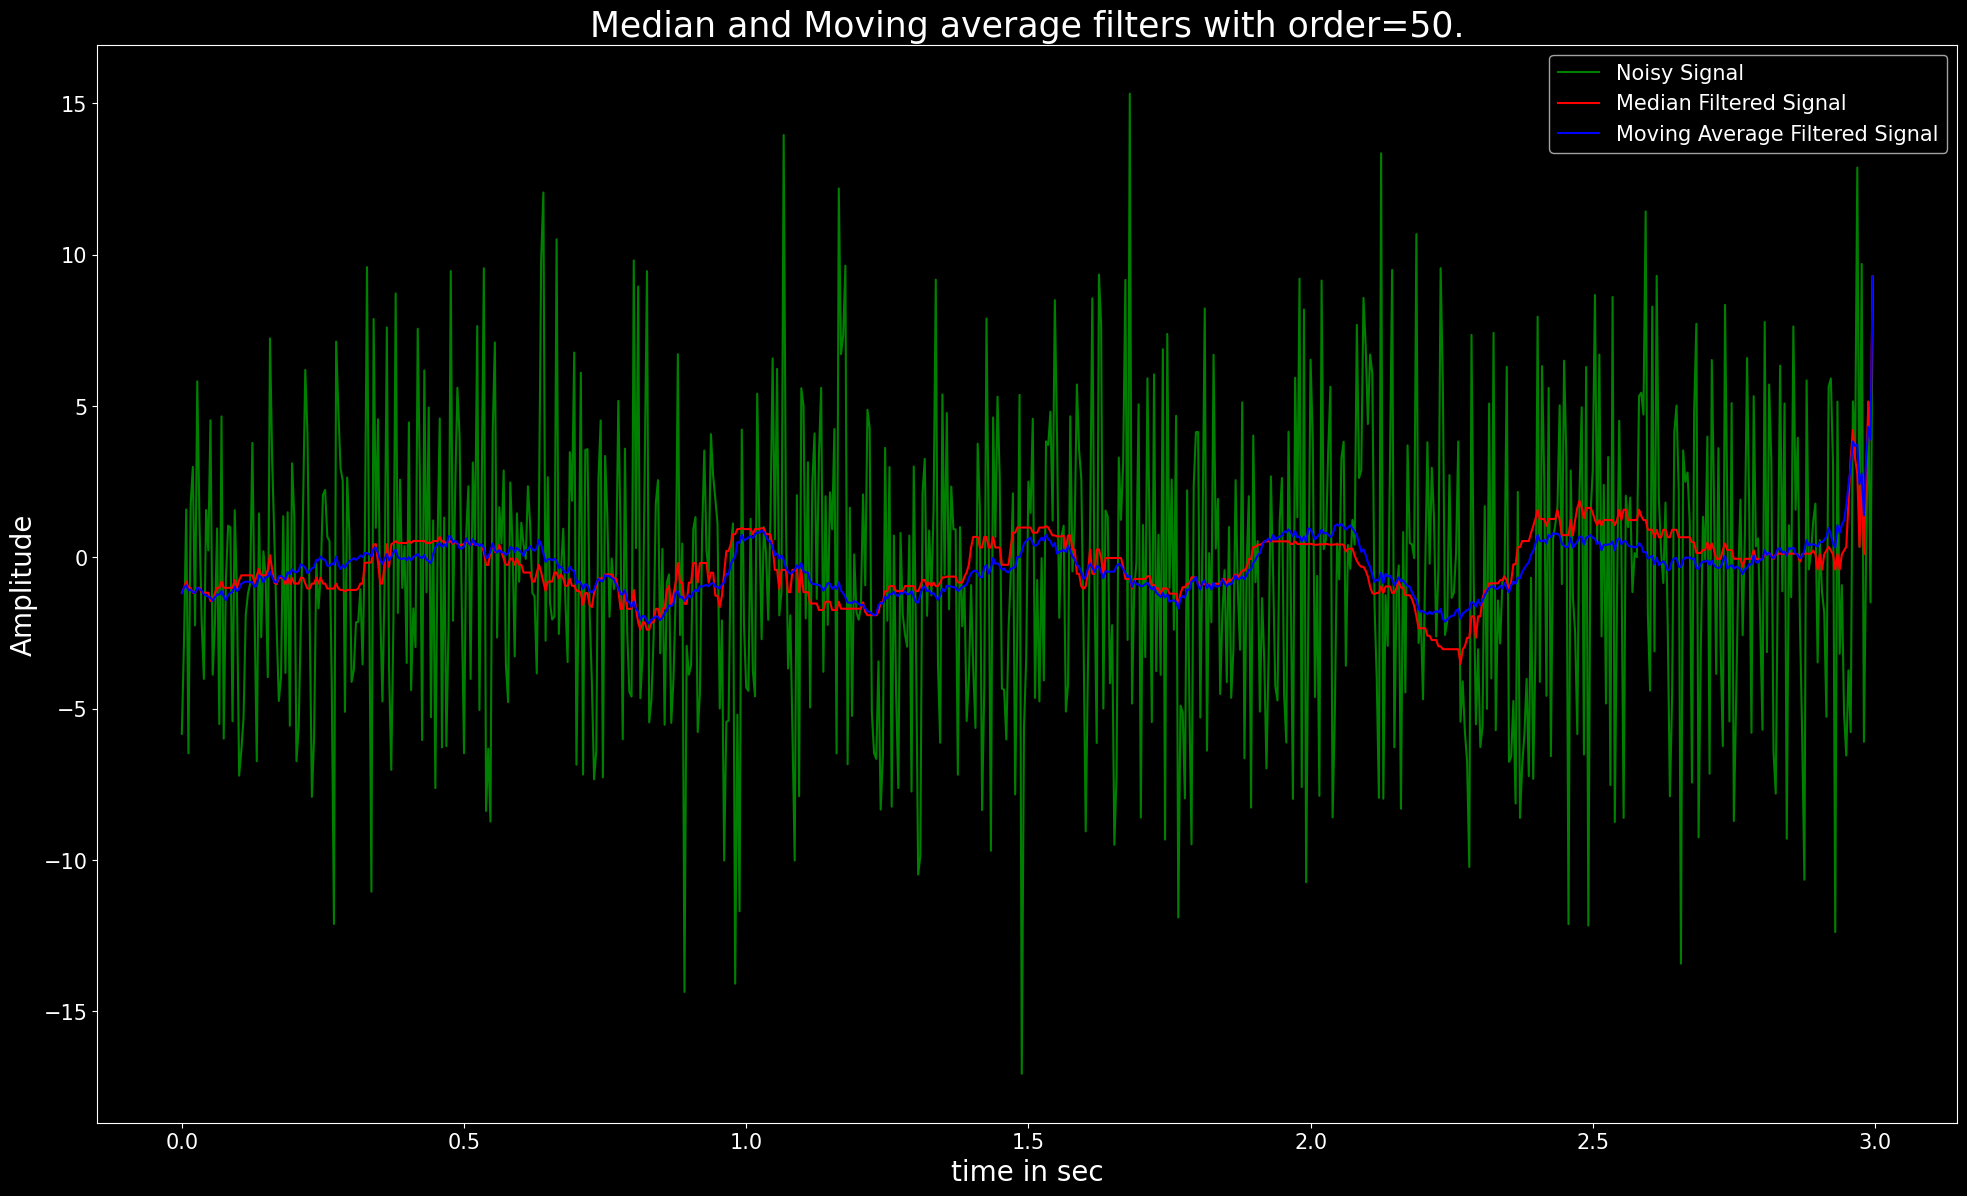

In [12]:
plt.figure(figsize= (24,14))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t, signal, 'g-', label = 'Noisy Signal')
plt.plot(t, filt_sig, 'r-', label = 'Median Filtered Signal')
plt.plot(t, mean_filt_sig, 'b-', label = 'Moving Average Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Median and Moving average filters with order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Recovering signal from noisy spikes by MedianFilter

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import style 
import pandas as pd 

In [ ]:
signal = pd.read_csv('Spike.csv')

In [ ]:
signal.head(10)

In [ ]:
signal = np.array(signal)

In [ ]:
spiky = abs(signal)

In [ ]:
len(spiky)

In [ ]:
spiky.shape

In [ ]:
plt.figure(figsize= (20,10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(spiky, label = 'signal with Spikes')
plt.legend(fontsize = 25)
plt.show()